In [1]:
# Autoreload
%load_ext autoreload
%autoreload 2

import pygad
from scripts import Optimizer,Character,Chromosome,get_item_set
import json
with open('data/MAPPED_ITEMS.json', 'r') as file:
    items = {i["ankama_id"]: i for i in json.load(file)}

with open('data/MAPPED_SETS.json', 'r') as file:
    item_sets = {i["ankama_id"]: i for i in json.load(file)}

In [ ]:
config = {
            "optimizer" : {
                "language": "es",
                "population_size": 300,
                "num_parents_mating": 100, # Number of parents to mate, usually 30%
                "num_generations": 500,
                "mutation_rate": 0.05,
                "crossover_rate": 0.8,
                "parent_selection_type": "tournament",  # Tournament Selection
                "tournament_size": 3,
                "exclusions": {
                    "items": [6894,
                              6895,
                              3080,
                              9031,
                              6980 # Vulbis
                              ]  # Excluded items
                },
                "preferences": {
                    "lower": {
                        12: 12,  # AP
                        8: 6,   # MP
                        29: 75,   # Crit
                        9 : 2000, # Vit
                    },
                    "upper": {} 
                },
                "elements" : [
                    36, # Agility,
                    22, # Chance
                    13, # Intelligence
                    45  # Strength
                ],
                "level_offset": 10,  # Level offset for items
                "objective": "weapon",  # Objective to optimize, can be "weapon" or "elements"
            },
            "character": {
                "level": 200,
                "scrolled": True,
                "exo": {
                    12:1, # Exo AP
                    8:1
                    }  # Exo MP
            },
        }
config["language"] = config["optimizer"]["language"]

In [3]:
import pandas as pd

effect_descriptions = {}
for _,item in items.items():
    if not item["effects"]:
        continue
    for effect in item["effects"]:
        effect_descriptions[effect["element_id"]] = effect["type"]

dct = {}
for k,v in items.items():
    item_set = get_item_set(v,item_sets)
    dct[k] = {
        "name" : v["name"][config["language"]],
        "set" : item_set["name"][config["language"]] if item_set else None,
    }
Items = pd.DataFrame.from_dict(dct, orient='index')

In [4]:
char = Character(**config["character"])
opt = Optimizer(char, items, item_sets, **config["optimizer"])

Total pools: 16 with sizes [69, 118, 71, 71, 62, 81, 40, 88, 69, 145, 326, 326, 326, 326, 326, 326]
Total combinations: 10^33.94


In [5]:
opt.optimize()

In [6]:
(opt.solution.fitness, opt.solution.get_final_weapon_damage())

(922.1333333333332, 1383.1999999999998)

In [7]:
opt.solution.totals_summary(effect_descriptions,
                      language=config["language"])#.sort_values("value",ascending=False)

,description,value
0,Intercambiable:,0.0
8,PM,6.0
9,vitalidad,2900.0
10,sabiduría,395.0
12,PA,11.0
13,inteligencia,170.0
16,% resistencia al aire,20.0
17,% resistencia al agua,18.0
22,suerte,300.0
24,iniciativa,700.0


In [8]:
set_summary = opt.solution.set_summary(language=config["language"])
set_summary

,type_id,type,description,level,set
694,13,Dofus,Dofus Púrpura,110,None
739,13,Dofus,Dofus Turquesa,160,None
7043,13,Dofus,Dofus de los hielos,180,None
11738,3,Anillo,Anillo Chanicomo,194,None
13125,5,Bota,Botas de Allister,191,Set de Allister
13344,13,Dofus,Dolmanax,100,None
13673,12,Mascota,Lokulto,20,None
14094,1,Amuleto,Amuleto de estrígido,200,Set de estrígido
14095,4,Cinturón,Cinturón de estrígido,200,Set de estrígido
14168,11,Capa,Capa Pología,198,None


In [9]:
set_summary["set"].value_counts()

set
Set de Allister            2
Set de estrígido           2
Set de Corrupción          1
Set de Wulán               1
Set de los Martilloseco    1
Name: count, dtype: int64

Text(0, 0.5, 'Best Fitness')

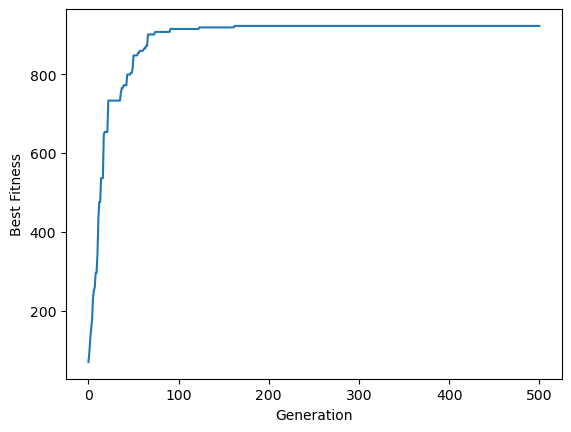

In [10]:
import matplotlib.pyplot as plt
plt.plot(opt.ga_instance.best_solutions_fitness)
plt.xlabel('Generation')
plt.ylabel('Best Fitness')

In [11]:
assert False

AssertionError: 

In [ ]:
chr = Chromosome(char,
                 items,
                 item_sets,
                 [
                    8993, # Espada
                    13641, 13643, 13642, # Noai
                    14161, 14162, 14169, # Charlatan
                    19985, # Vuelo
                    18670, # Escudo
                    13673, # Lokulto
                    739, 694, 7754, 737, 7043, 17078 # Dofus
                 ],
                 config["optimizer"]["preferences"],
                 elements=config["optimizer"]["elements"],
                 objective=config["optimizer"]["objective"],)
chr.fitness

1890.67

In [ ]:
chr = Chromosome(char,
                 items,
                 item_sets,
                 [
                    8993, # Espada
                    13641, 13642, # Noai
                    14161, 14162, 14169, # Charlatan
                    14092, 14093, 18718, # Kuko
                    13673, # Lokulto
                    739, 694, 7754, 737, 7043, 17078 # Dofus
                 ],
                 config["optimizer"]["preferences"],
                 elements=config["optimizer"]["elements"],
                 objective=config["optimizer"]["objective"],)
chr.fitness

2049.74

In [ ]:
Items[Items["name"].str.contains("noai", case=False)]

,name,set
13641,Gorro de Noai Aludem,Set de Noai Aludem
13643,Getas de Noai Aludem,Set de Noai Aludem
13642,Anillo de Noai Aludem,Set de Noai Aludem


In [ ]:
chr.set_summary(language=config["language"])

,type_id,type,description,level,set
694,13,Dofus,Dofus Púrpura,110,None
737,13,Dofus,Dofus Esmeralda,100,None
739,13,Dofus,Dofus Turquesa,160,None
7043,13,Dofus,Dofus de los hielos,180,None
7754,13,Dofus,Dofus Ocre,160,None
8993,2,Espada,Espada maldita del gran Desangrador Guerrero,200,None
13641,10,Sombrero,Gorro de Noai Aludem,198,Set de Noai Aludem
13642,3,Anillo,Anillo de Noai Aludem,197,Set de Noai Aludem
13673,12,Mascota,Lokulto,20,None
14092,3,Anillo,Anillo de kukoloide,200,Set de kukoloide


In [ ]:
chr.set_summary(language=config["optimizer"]["language"])["set"].value_counts()

set
Set de kukoloide      3
Set de charlatán      3
Set de Noai Aludem    2
Name: count, dtype: int64

In [ ]:
chr.totals_summary(effect_descriptions,
                      language=config["language"])

,description,value
0,Intercambiable:,0.0
8,PM,6.0
9,vitalidad,2365.0
10,sabiduría,390.0
12,PA,12.0
13,inteligencia,550.0
14,de resistencia al fuego,35.0
15,de resistencia a la tierra,10.0
16,% resistencia al aire,34.0
17,% resistencia al agua,46.0


In [ ]:
Items[Items["name"].str.contains("Chani")]

,name,set
11738,Anillo Chanicomo,None


In [ ]:
item = items[21392]
# item = items[6981]

In [ ]:
chr.are_item_conditions_met(item)

False

In [ ]:
item

{'ankama_id': 21392,
 'type': {'id': 190,
  'name': {'de': 'Zaumzeuge des Dracotruters',
   'en': 'Dragoturkey Harnesses',
   'es': 'Arreos de dragopavo',
   'fr': 'Harnachements de Dragodinde',
   'pt': 'Arreios de Dragoperu'},
  'itemTypeId': 130,
  'superTypeId': 24,
  'categoryId': 5},
 'description': {'de': 'Dieses Zaumzeug ist ideal für Paraden geeignet und schützt euer Reittier vor Geschrei und Blütenblättern.',
  'en': 'This harness is ideal for parading around and will protect your mount from yelling and flower petals.',
  'es': 'Ideal para desfilar, estos arreos protegerán a tu montura de los gritos y los pétalos de flores.',
  'fr': 'Idéal pour parader, ce harnachement protègera votre monture des cris et des pétales de fleur.',
  'pt': 'Ótimos para exibir, estes arreios são o que há de melhor para proteger sua montaria contra gritos e pétalas de flores.'},
 'name': {'de': 'Azurblaues Zaumzeug des Dracotruters',
  'en': 'Azure Dragoturkey Harness',
  'es': 'Arreos azulados de

In [ ]:
Items

,name,set
11849,Nuevo modelo de calzón frigosteño,None
27434,Armadura de blinduro,None
14629,Makinturón,None
27104,Colada de garudán,Set cosmético de garudán
1373,La Afeitadora Infernal,None
...,...,...
13940,Crines de xakal,None
12231,Pequeña caja de corazón,None
16035,Fragmento del mapa de Hiperescampo 4/8,None
31924,Caja de ofrendas a Gargandias,None


In [ ]:
lst

False

In [ ]:
lst[0][2]

[False, False, [...], True]

In [ ]:
chr.are_item_conditions_met(items[11738])

False

In [ ]:
items[11738]["conditions"]

{'value': None,
 'is_operand': False,
 'relation': 'or',
 'children': [{'value': {'element': 'CP',
    'element_id': 12,
    'operator': '<',
    'value': 12,
    'templated': {'de': 'AP', 'en': 'AP', 'es': 'PA', 'fr': 'PA', 'pt': 'PA'}},
   'is_operand': True,
   'relation': None,
   'children': None},
  {'value': {'element': 'CM',
    'element_id': 8,
    'operator': '<',
    'value': 6,
    'templated': {'de': 'BP', 'en': 'MP', 'es': 'PM', 'fr': 'PM', 'pt': 'PM'}},
   'is_operand': True,
   'relation': None,
   'children': None}]}

In [ ]:
chr.totals[8]

6.0

[(1, 1),
 (2, 1),
 (3, 2),
 (4, 1),
 (5, 1),
 (7, 1),
 (10, 1),
 (11, 1),
 (12, 1),
 (13, 6)]

In [ ]:
lst = []
for i in items.values():
    if i["type"]["superTypeId"] not in [i[0] for i in opt.pool_types]:
        continue
    if i["conditions"]:
        print(opt.solution.are_item_conditions_met(i))
        lst.append((i,opt.solution.are_item_conditions_met(i)))

True
False
True
False
True
True
False
True
False
True
False
True
True
False
True
True
True
False
True
True
True
False
False
True
True
True
False
True
False
False
False
True
True
True
True
False
False
True
False
True
False
True
True
False
True
True
False
True
True
True
True
True
False
True
False
True
False
False
True
True
False
True
False
False
True
False
False
False
False
False
False
False
False
False
False
False
True
True
True
True
True
False
False
True
True
False
False
True
True
True
False
True
True
False
True
False
False
False
True
False
True
False
True
False
True
True
True
False
False
True
False
False
False
False
True
False
False
True
False
True
False
False
True
False
True
False
True
True
True
True
False
True
False
True
False
True
False
True
False
True
False
True
False
True
True
True
False
True
False
False
False
True
False
False
False
False
False
True
True
True
False
False
False
True
False
False
True
True
False
False
False
True
True
True
True
False
False
False
True
False
False
Fals

In [ ]:
lst[1]

({'ankama_id': 16194,
  'type': {'id': 151,
   'name': {'de': 'Trophäe',
    'en': 'Trophy',
    'es': 'Trofeo',
    'fr': 'Trophée',
    'pt': 'Troféu'},
   'itemTypeId': 23,
   'superTypeId': 13,
   'categoryId': 0},
  'description': {'de': 'Der Schaum vor dem Mund wird euch helfen, die Spuren eines Schnelms zu imitieren, wenn ihr in den Staub beißt.',
   'en': 'The saliva on your lips allows you to create a Snailmet trail when you bite the dust.',
   'es': 'La baba de tus labios hará que simules el paso de un kasrakol cuando muerdas el polvo.',
   'fr': "La bave sur vos lèvres vous permettra de simuler le passage d'un Kaskargo lorsque vous mordrez la poussière.",
   'pt': 'Ao ser derrotado e cair de cara no chão, a saliva em seus lábios permite simular um rastro de Krakol.'},
  'name': {'de': 'Kleiner Tobsüchtiger',
   'en': 'Minor Rabid',
   'es': 'Rabioso menor',
   'fr': 'Enragé mineur',
   'pt': 'Raivoso menor'},
  'image': 'https://static.ankama.com/dofus/www/game/items/200/151

In [ ]:
lst.count(True), lst.count(False)

(221, 649)